In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 1. Loading the Dataset  

In [133]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target
df["species_name"] = iris.target_names[iris.target]

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## Exploratory Data Analysis (EDA)
### Dataset Overview

In [134]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
print(df.describe())

print("\nSpecies Distribution:")
print(df["species"].value_counts())

Shape: (150, 6)

Columns:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species', 'species_name'],
      dtype='str')

Data Types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
species_name             str
dtype: object

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

Descriptive Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000     

### Pairplot

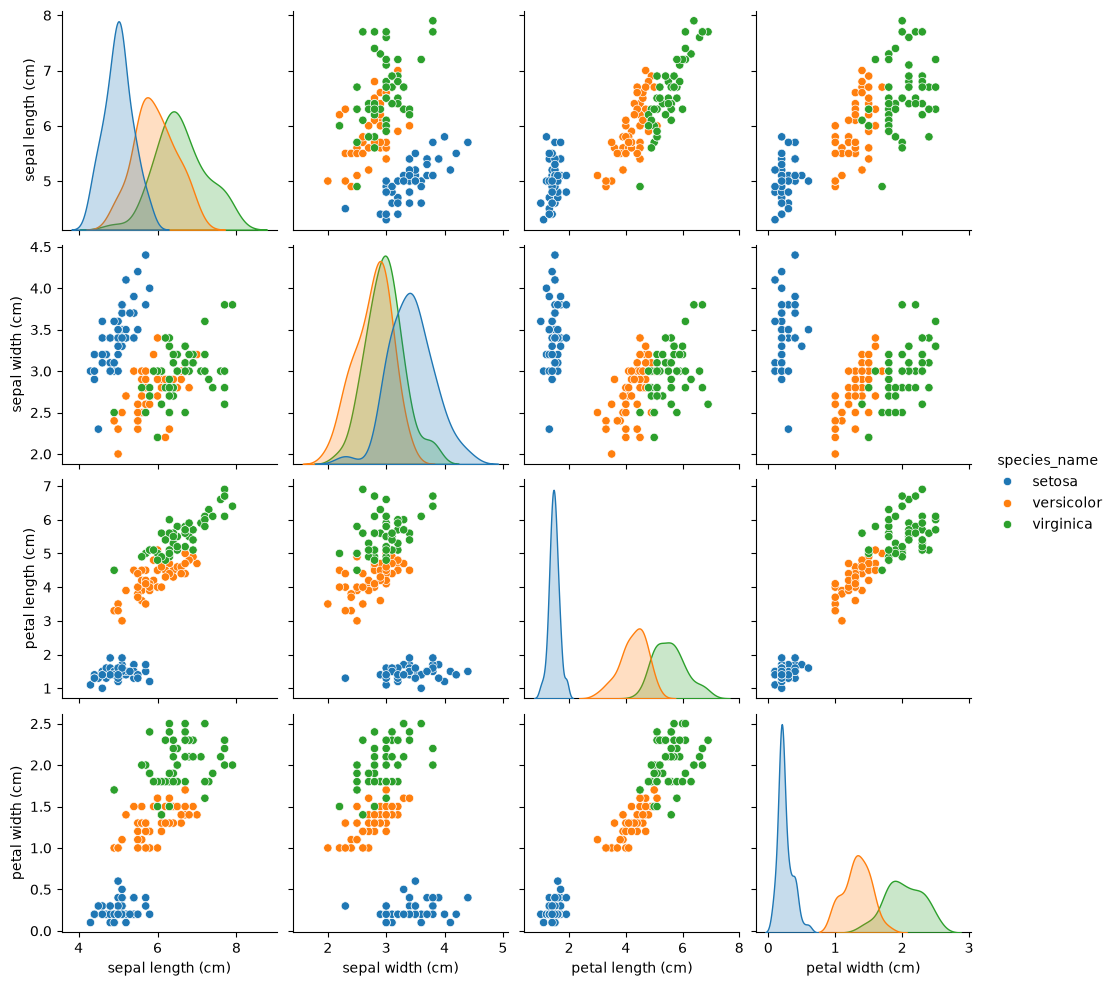

In [135]:
features = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
    ]

sns.pairplot(df, vars=features, hue="species_name")
plt.show()

The pairplot shows the relationships between the four flower measurements. We can see that Setosa is separated from Versicolor and Virginica, which overlap with each other.

### Box Plots

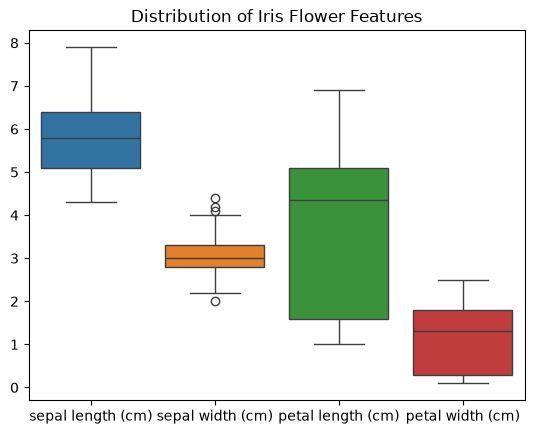

In [136]:
sns.boxplot(data=df[features])
plt.title("Distribution of Iris Flower Features")
plt.show()

The box plots show the distributions of the four numerical features. Sepal width contains some potential outliers, whereas the other features appear relatively concentrated.

### Feature Selection

Based on the pairplot, petal length and petal width appear to be the most useful features for distinguishing between the three species, as they show clearer separation than the sepal measurements. However, all four numerical features are retained for model training so that the models can use all available information.

## 2. Preparing Data for Machine Learning

In [137]:
X = df[features]
y = df["species"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


### Train-Test Split

In [138]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (120, 4)
X_test: (30, 4)
y_train: (120,)
y_test: (30,)


The dataset is divided into 80% training data and 20% testing data. The training set is used to train the models, while the testing set is kept separate to evaluate their performance on unseen data.

## 3. Logistic Regression

In [139]:
logistic_model = LogisticRegression()

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

print("Predictions:")
print(y_pred)

print("\nActual values:")
print(y_test.values)

Predictions:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]

Actual values:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


### Logistic Regression Evaluation

In [140]:
logistic_accuracy = accuracy_score(y_test, y_pred)
logistic_cm = confusion_matrix(y_test, y_pred)
logistic_report = classification_report(y_test, y_pred)

print("Accuracy:", logistic_accuracy)

print("\nConfusion Matrix:")
print(logistic_cm)

print("\nClassification Report:")
print(logistic_report)

Accuracy: 1.0

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



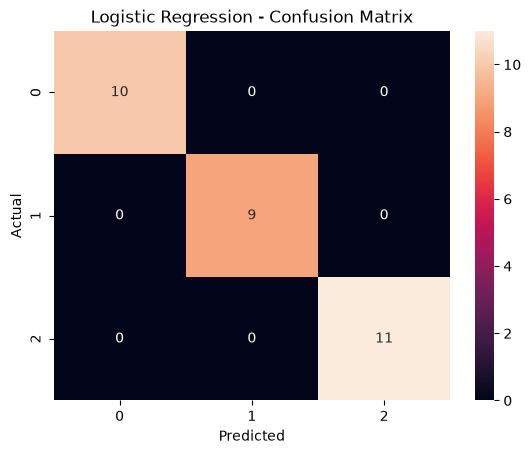

In [141]:
sns.heatmap(logistic_cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

## 4. K-Nearest Neighbors (KNN)

In [142]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

print("Predictions:")
print(knn_pred)

print("\nActual values:")
print(y_test.values)

Predictions:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]

Actual values:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


### KNN Evaluation

In [143]:
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_cm = confusion_matrix(y_test, knn_pred)
knn_report = classification_report(y_test, knn_pred)

print("Accuracy:", knn_accuracy)

print("\nConfusion Matrix:")
print(knn_cm)

print("\nClassification Report:")
print(knn_report)

Accuracy: 1.0

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



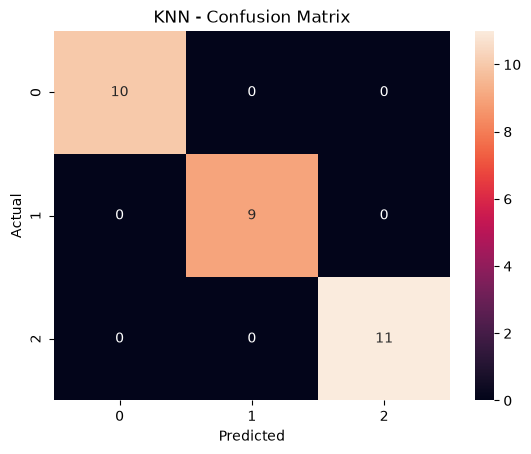

In [144]:
sns.heatmap(knn_cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN - Confusion Matrix")
plt.show()

## 5. Model Comparison and Conclusion

In [145]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN"],
    "Accuracy": [logistic_accuracy, knn_accuracy]
})

comparison

,Model,Accuracy
0,Logistic Regression,1.0
1,KNN,1.0


Based on the evaluation results, both Logistic Regression and K-Nearest Neighbors (KNN) achieved 100% accuracy on the test set. Both models also produced identical precision, recall, F1-scores, and confusion matrices. Therefore, neither model outperformed the other based on the evaluation metrics used. Since both models achieved the same results, either model could be selected for this dataset.
